In [3]:
import pickle
import numpy as np

# Define file paths in the current Colab workspace
train_x_path = 'CSCE-636-Project-1-Train-n_k_m_P'
train_y_path = 'CSCE-636-Project-1-Train-mHeights'

# Load input features (raw_train_x)
with open(train_x_path, 'rb') as f:
    raw_train_x = pickle.load(f)

# Load target labels (raw_train_y)
with open(train_y_path, 'rb') as f:
    raw_train_y = pickle.load(f)

# Verify dataset size
print(f"Total training samples (X): {len(raw_train_x)}")
print(f"Total training labels (y): {len(raw_train_y)}")

# Display details of the first sample
sample_n, sample_k, sample_m, sample_P = raw_train_x[0]
print("\n--- Sample 0 Details ---")
print(f"n: {sample_n}")
print(f"k: {sample_k}")
print(f"m: {sample_m}")
print(f"P matrix shape: {sample_P.shape}")
print(f"P matrix content:\n{sample_P}")
print(f"Target m-height (y): {raw_train_y[0]}")


def preprocess_sample(sample, max_p_length=20):
    """
    Flattens matrix P, pads it with zeros to a uniform length of 20,
    and concatenates with [n, k, m] to create a fixed-size feature vector.
    """
    n, k, m, P = sample
    P_flat = P.flatten()

    # Pad zeros to ensure vector length matches maximum P size (k=4, n-k=5 -> 20 elements)
    padded_P = np.pad(P_flat, (0, max_p_length - len(P_flat)), mode='constant')

    # Combine features: [n, k, m, P_0, P_1, ..., P_19] -> total length = 23
    return np.concatenate(([n, k, m], padded_P))

# Convert raw data into formatted 2D NumPy arrays
X_train = np.array([preprocess_sample(s) for s in raw_train_x], dtype=np.float32)
y_train = np.array(raw_train_y, dtype=np.float32)

print("\n--- Processed Dataset Shapes ---")
print(f"X_train shape: {X_train.shape}")  # Output: (3833203, 23)
print(f"y_train shape: {y_train.shape}")  # Output: (3833203,)

Total training samples (X): 3833203
Total training labels (y): 3833203

--- Sample 0 Details ---
n: 9
k: 4
m: 4
P matrix shape: (4, 5)
P matrix content:
[[  7.  29.  32.  33. -42.]
 [ 24.  38.  -3.  26.  17.]
 [ 28. -35. -20.  32. -29.]
 [-32. -14.   1. -47. -18.]]
Target m-height (y): 415.96346010439976

--- Processed Dataset Shapes ---
X_train shape: (3833203, 23)
y_train shape: (3833203,)


In [4]:
import keras
from keras import layers, optimizers
from keras.regularizers import l2
import numpy as np

# Validation
x_val = X_train[:100000]
partial_x_train = X_train[100000:]

y_val = y_train[:100000]
partial_y_train = y_train[100000:]

partial_z_train = np.log2(partial_y_train)
z_val = np.log2(y_val)

#Standard
norm_layer = layers.Normalization()
norm_layer.adapt(partial_x_train)

# Input Layer
inputs = keras.Input(shape=(23,))
x = norm_layer(inputs)

#n k m
struct_feat = layers.Lambda(lambda t: t[:, :3])(x) #:means all data; :3 means the first 3 data
struct_branch = layers.Dense(256, activation='elu')(struct_feat)

#P
p_feat = layers.Lambda(lambda t: t[:, 3:])(x) #3: means all the data which is behind 3
p_branch = layers.Dense(1024, activation='elu')(p_feat)
p_branch = layers.Dense(1024, activation='elu')(p_branch)
p_branch = layers.Dropout(0.15)(p_branch)

# 128+512=640
merged = layers.Concatenate()([struct_branch, p_branch])

x = layers.Dense(2048)(merged)
x = layers.BatchNormalization()(x)
x = layers.Activation('elu')(x)

# Res1
res1 = x
x = layers.Dense(2048)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('elu')(x)
x = layers.Dropout(0.15)(x)
x = layers.Dense(2048)(x)
x = layers.BatchNormalization()(x)
x = layers.add([x, res1])
x = layers.Activation('elu')(x)

#Res2
res2 = x
x = layers.Dense(2048)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('elu')(x)
x = layers.Dropout(0.15)(x)
x = layers.Dense(2048)(x)
x = layers.BatchNormalization()(x)
x = layers.add([x, res2])
x = layers.Activation('elu')(x)

#Res3
res3 = x
x = layers.Dense(2048)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('elu')(x)
x = layers.Dropout(0.15)(x)
x = layers.Dense(2048)(x)
x = layers.BatchNormalization()(x)
x = layers.add([x, res3])
x = layers.Activation('elu')(x)

x = layers.Dense(512)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('elu')(x)
x = layers.Dropout(0.15)(x)

x = layers.Dense(128)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('elu')(x)

# Output Layer (z_hat = log2(y_hat))
outputs = layers.Dense(1)(x)

#Cos Learning Rate Schedule
epochs = 70
batch_size = 1024
total_steps = (len(partial_x_train) // batch_size) * epochs

lr_schedule = optimizers.schedules.CosineDecay(
    initial_learning_rate=0.0025,
    decay_steps=total_steps,
    alpha=1e-5 / 0.0025
)

model = keras.Model(inputs=inputs, outputs=outputs)
model.compile(optimizer=optimizers.AdamW(
        learning_rate=lr_schedule,
        weight_decay=1e-4), loss='mean_squared_error')

callbacks_list = [
    keras.callbacks.ModelCheckpoint("best_model.keras", monitor='val_loss', save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
]

history = model.fit(partial_x_train, partial_z_train, epochs=epochs, batch_size=batch_size, validation_data=(x_val, z_val), callbacks = callbacks_list)

best_model = keras.models.load_model("best_model.keras", safe_mode=False)

val_loss = best_model.evaluate(x_val, z_val)
print(f"Best Model MSE Loss: {val_loss}")





Epoch 1/70
3646/3646 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 4.8636
Epoch 1: val_loss improved from None to 0.85818, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
3646/3646 ━━━━━━━━━━━━━━━━━━━━ 97s 20ms/step - loss: 1.6642 - val_loss: 0.8582
Epoch 2/70
3645/3646 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.8289
Epoch 2: val_loss improved from 0.85818 to 0.74273, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
3646/3646 ━━━━━━━━━━━━━━━━━━━━ 56s 15ms/step - loss: 0.8044 - val_loss: 0.7427
Epoch 3/70
3645/3646 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.7514
Epoch 3: val_loss improved from 0.74273 to 0.71692, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
3646/3646 ━━━━━━━━━━━━━━━━━━━━ 57s 16ms/step - loss: 0.7437 - val_loss: 0.7169
Epoch 4/70
3645/3646 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.7174
Epoch 4: val_loss improved from 0.71692 to 0.71262, saving model to best_mo

In [6]:
# 2. Log2  output
val_loss_z = best_model.evaluate(x_val, z_val, verbose=0)
print(f"Best Model Log2-MSE Loss: {val_loss_z:.6f}")

# 3. z_val -> y (mHeights)
z_val_pred = best_model.predict(x_val, batch_size=2048)
y_val_pred = np.power(2.0, z_val_pred.flatten())

# 4. y's MSE  MAE
val_mse_y = np.mean((y_val - y_val_pred) ** 2)
val_mae_y = np.mean(np.abs(y_val - y_val_pred))

print(f"Best Model Original y-Scale MSE: {val_mse_y:.4f}")
print(f"Best Model Original y-Scale MAE: {val_mae_y:.4f}")

#
print("\n--- Sample Validation Predictions (Original Scale y) ---")
for i in range(5):
    print(f"Sample {i} - True y: {y_val[i]:.4f} | Predicted y: {y_val_pred[i]:.4f}")

Best Model Log2-MSE Loss: 0.619832
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step
Best Model Original y-Scale MSE: 6396279296.0000
Best Model Original y-Scale MAE: 6833.2090

--- Sample Validation Predictions (Original Scale y) ---
Sample 0 - True y: 415.9635 | Predicted y: 456.8428
Sample 1 - True y: 176.9246 | Predicted y: 195.5371
Sample 2 - True y: 34.1568 | Predicted y: 29.0399
Sample 3 - True y: 61.3871 | Predicted y: 46.7259
Sample 4 - True y: 42.0000 | Predicted y: 62.2833


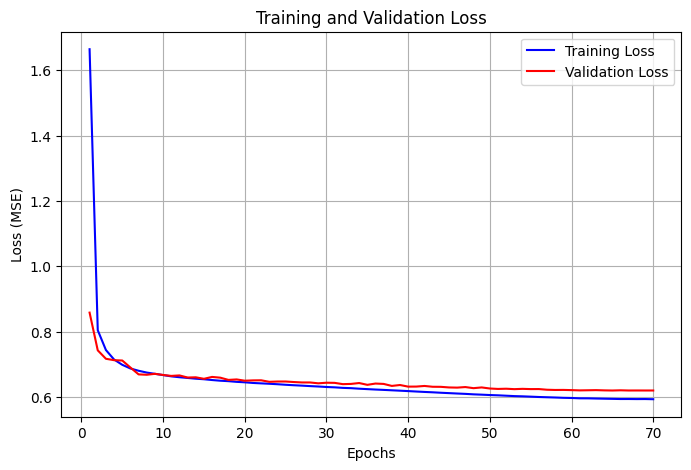

In [5]:
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

# plot
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, 'b-', label='Training Loss')
plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# prediction
test_x_path = 'CSCE-636-Project-1-Test-n_k_m_P'

with open(test_x_path, 'rb') as f:
    raw_test_x = pickle.load(f)

print(f"Total test samples: {len(raw_test_x)}")


X_test = np.array([preprocess_sample(s) for s in raw_test_x], dtype=np.float32)


z_test_pred = best_model.predict(X_test, batch_size=2048)

y_test_pred = np.power(2.0, z_test_pred.flatten())


print("\n--- Test Predictions Preview ---")
print(f"Shape of y_test_pred: {y_test_pred.shape}")
print(f"First 5 predictions: {y_test_pred[:5]}")


with open('predicted_mHeights.pkl', 'wb') as f:
    pickle.dump(y_test_pred, f)

print("\nSuccessfully saved predictions to 'predicted_mHeights.pkl'!")